Authors: Brooklyn Pagaza (A17847284) and Sai Sri Lasya Yadlapati (A17773868)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

This file contains all of our code for our exploratory data analysis, baseline models, and final model.

We also created a demo so that you could try out our final model at this link: https://employee-monthly-salary-prediction.streamlit.app/.

We also have a GitHub repository with the raw data and the files needed to create the demo. If you'd like to take a look, here's the link: https://github.com/broooklynp/EmployeePrediction/.

# Import Dataset

In [52]:
data = pd.read_csv('Employee_Performance_and_Productivity_Data.csv')
data

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,Finance,Male,27,Technician,2022-12-07 08:03:05.556036,1,Bachelor,4,4900.0,55,46,5,3,75,16,48,2,1.28,False
99996,99997,IT,Female,36,Consultant,2018-07-24 08:03:05.556036,6,Master,5,8250.0,39,35,7,0,0,10,77,1,3.48,True
99997,99998,Operations,Male,53,Analyst,2015-11-24 08:03:05.556036,8,High School,2,4800.0,31,13,6,5,0,5,87,1,2.60,False
99998,99999,HR,Female,22,Consultant,2015-08-03 08:03:05.556036,9,High School,5,8250.0,35,43,10,1,75,2,31,1,3.10,False


# Basic Statistics

In [3]:
data.shape

(100000, 20)

In [4]:
data.columns

Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date',
       'Years_At_Company', 'Education_Level', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned'],
      dtype='object')

In [5]:
data.describe()

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
std,28867.657797,11.244121,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719
min,1.000000,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


# Data Cleaning

In [6]:
data_cleaned = data.drop(columns=['Employee_ID', 'Resigned'])
data_cleaned

,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63
1,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72
2,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17
3,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86
4,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Finance,Male,27,Technician,2022-12-07 08:03:05.556036,1,Bachelor,4,4900.0,55,46,5,3,75,16,48,2,1.28
99996,IT,Female,36,Consultant,2018-07-24 08:03:05.556036,6,Master,5,8250.0,39,35,7,0,0,10,77,1,3.48
99997,Operations,Male,53,Analyst,2015-11-24 08:03:05.556036,8,High School,2,4800.0,31,13,6,5,0,5,87,1,2.60
99998,HR,Female,22,Consultant,2015-08-03 08:03:05.556036,9,High School,5,8250.0,35,43,10,1,75,2,31,1,3.10


In [7]:
data_cleaned['Hire_Date'] = pd.to_datetime(data_cleaned['Hire_Date']).dt.date
data_cleaned

,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2022-01-19,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63
1,Finance,Male,29,Developer,2024-04-18,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72
2,Finance,Male,55,Specialist,2015-10-26,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17
3,Customer Support,Female,48,Analyst,2016-10-22,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86
4,Engineering,Female,36,Analyst,2021-07-23,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Finance,Male,27,Technician,2022-12-07,1,Bachelor,4,4900.0,55,46,5,3,75,16,48,2,1.28
99996,IT,Female,36,Consultant,2018-07-24,6,Master,5,8250.0,39,35,7,0,0,10,77,1,3.48
99997,Operations,Male,53,Analyst,2015-11-24,8,High School,2,4800.0,31,13,6,5,0,5,87,1,2.60
99998,HR,Female,22,Consultant,2015-08-03,9,High School,5,8250.0,35,43,10,1,75,2,31,1,3.10


# Exploratory Data Analysis

Text(0.5, 1.0, 'Distribution of Monthly Salary')

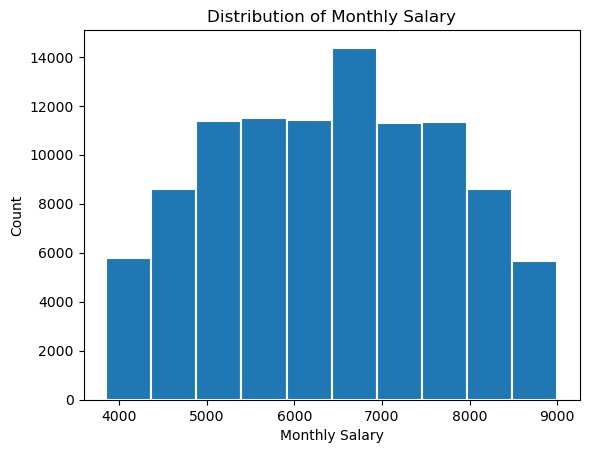

In [8]:
# Histogram of monthly salary
plt.hist(data_cleaned['Monthly_Salary'], edgecolor='white', linewidth=1.5)
plt.xlabel('Monthly Salary')
plt.ylabel('Count')
plt.title('Distribution of Monthly Salary')

Text(0.5, 1.0, 'Distribution of Education Level')

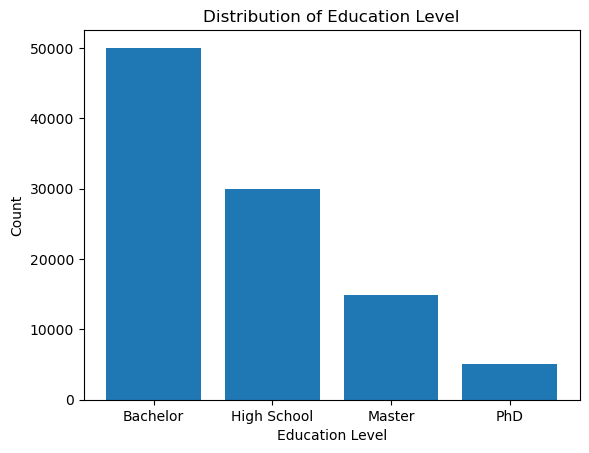

In [9]:
plt.bar(['Bachelor', 'High School', 'Master', 'PhD'], data_cleaned.groupby('Education_Level')['Monthly_Salary'].count().array)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Distribution of Education Level')

<Axes: xlabel='Job_Title'>

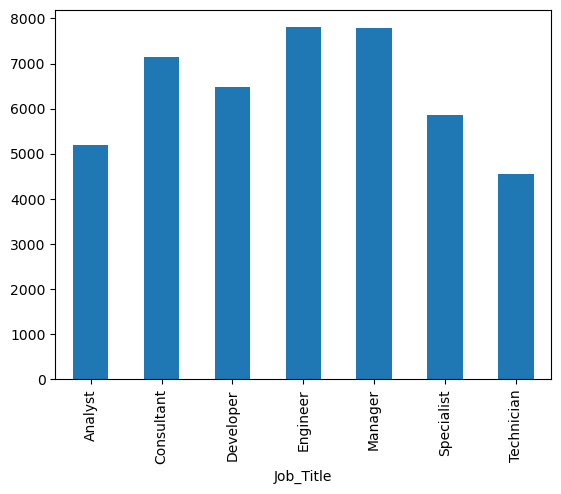

In [10]:
# Bar chart of average monthly salaries for each job title
data_cleaned.groupby('Job_Title')['Monthly_Salary'].mean().plot(kind='bar')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Analyst'),
  Text(1, 0, 'Consultant'),
  Text(2, 0, 'Developer'),
  Text(3, 0, 'Engineer'),
  Text(4, 0, 'Manager'),
  Text(5, 0, 'Specialist'),
  Text(6, 0, 'Technician')])

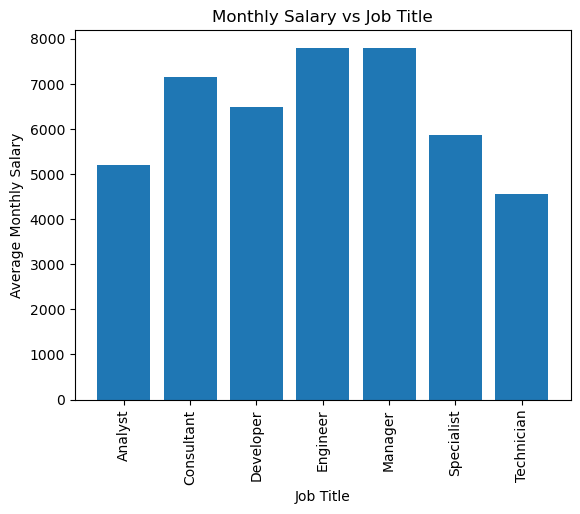

In [11]:
plt.bar(['Analyst', 'Consultant', 'Developer', 'Engineer', 'Manager', 'Specialist', 'Technician'], data_cleaned.groupby('Job_Title')['Monthly_Salary'].mean().array)
plt.xlabel('Job Title')
plt.ylabel('Average Monthly Salary')
plt.title('Monthly Salary vs Job Title')
plt.xticks(rotation=90)

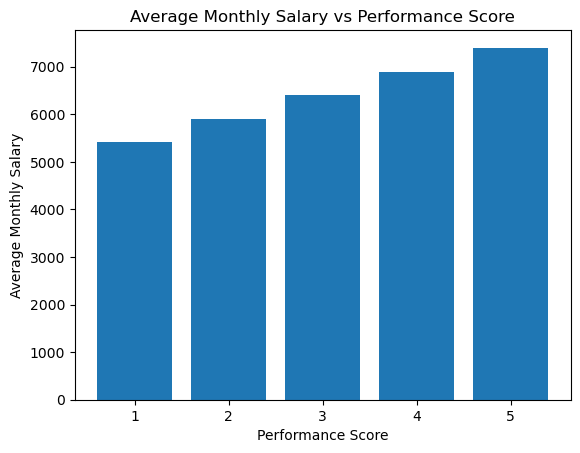

In [12]:
plt.bar([1, 2, 3, 4, 5], data_cleaned.groupby('Performance_Score')['Monthly_Salary'].mean().array);
plt.title('Average Monthly Salary vs Performance Score');
plt.xlabel('Performance Score');
plt.ylabel('Average Monthly Salary');

# Baseline Model

In [72]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVR

In [73]:
# Split data into features and labels
X = data_cleaned.drop('Monthly_Salary', axis=1)
y = data_cleaned['Monthly_Salary']

# Perform a train test split on the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Select features to use in the baseline model
X_train_baseline = X_train[['Years_At_Company', 'Performance_Score', 'Overtime_Hours', 'Promotions', 'Work_Hours_Per_Week',
                           'Sick_Days', 'Training_Hours', 'Employee_Satisfaction_Score']]
X_test_baseline = X_test[['Years_At_Company', 'Performance_Score', 'Overtime_Hours', 'Promotions', 'Work_Hours_Per_Week',
                         'Sick_Days', 'Training_Hours', 'Employee_Satisfaction_Score']]

In [74]:
# Create baseline linear regression model
linReg = LinearRegression().fit(X_train_baseline, y_train)

# Make predictions on the test set
baseline_linreg_preds = linReg.predict(X_test_baseline)

# Compute RMSE on the test set
baseline_linreg_rmse = np.sqrt(mean_squared_error(y_test, baseline_linreg_preds))
baseline_linreg_rmse

1183.7916906851142

In [59]:
# Create baseline random forest regressor
rf = RandomForestRegressor().fit(X_train_baseline, y_train)

# Make predictions on the test set
baseline_rf_preds = rf.predict(X_test_baseline)

# Compute RMSE on the test set
baseline_rf_rmse = np.sqrt(mean_squared_error(y_test, baseline_rf_preds))
baseline_rf_rmse

1208.9278619814336

In [60]:
# Create baseline support vector regressor
svr = LinearSVR().fit(X_train_baseline, y_train)

# Make predictions on the test set
baseline_svr_preds = svr.predict(X_test_baseline)

# Compute RMSE on the test set
baseline_svr_rmse = root_mean_squared_error(y_test, baseline_svr_preds)
baseline_svr_rmse

1261.6217067540142

In [61]:
# Create baseline xgb regressor
xgb_baseline = xgb.XGBRegressor().fit(X_train_baseline, y_train)

# Make predictions on the test set
baseline_xgb_preds = xgb_baseline.predict(X_test_baseline)

# Compute RMSE on the test set
baseline_xgb_rmse = root_mean_squared_error(y_test, baseline_xgb_preds)
baseline_xgb_rmse

1206.5391297842116

In [62]:
# Create baseline light gbm regressor
lgb_baseline = lgb.LGBMRegressor().fit(X_train_baseline, y_train)

# Make predictions on the test set
baseline_lgb_preds = lgb_baseline.predict(X_test_baseline)

# Compute RMSE on the test set
baseline_lgb_rmse = root_mean_squared_error(y_test, baseline_lgb_preds)
baseline_lgb_rmse

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000497 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 443
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 8
[LightGBM] [Info] Start training from score 6401.072143


1187.3115340194713

In [63]:
baseline_results_df = pd.DataFrame({'model': ['linear regression', 'random forest', 'support vector machine', 'xgboost', 
                                             'lightgbm'],
                                    'rmse': [baseline_linreg_rmse, baseline_rf_rmse, baseline_svr_rmse, baseline_xgb_rmse,
                                            baseline_lgb_rmse]})
baseline_results_df.sort_values(by='rmse').reset_index().drop('index', axis=1)

,model,rmse
0,linear regression,1176.779791
1,lightgbm,1187.311534
2,xgboost,1206.539130
3,random forest,1208.927862
4,support vector machine,1261.621707


# Final Model

In [75]:
# Select features to use in the final model
X_train_final = X_train[['Years_At_Company', 'Performance_Score', 'Overtime_Hours', 'Promotions', 'Work_Hours_Per_Week',
                           'Sick_Days', 'Training_Hours', 'Employee_Satisfaction_Score', 'Department', 'Gender', 'Job_Title', 
                           'Education_Level']]
X_test_final = X_test[['Years_At_Company', 'Performance_Score', 'Overtime_Hours', 'Promotions', 'Work_Hours_Per_Week',
                         'Sick_Days', 'Training_Hours', 'Employee_Satisfaction_Score', 'Department', 'Gender', 'Job_Title', 
                           'Education_Level']]

In [76]:
# Create preprocessor to handle one hot encoding for the final model
preproc_final = ColumnTransformer(transformers=[
     ('categorical_cols', OneHotEncoder(handle_unknown='ignore'), ['Department', 'Gender', 'Job_Title', 'Education_Level']),
    ], remainder='passthrough'
    )

In [77]:
# Build linear regression final model pipeline
linreg_final = Pipeline([('preprocessor', preproc_final), ('lr', LinearRegression())])

# Fit to the training data
linreg_final.fit(X_train_final, y_train)

# Make predictions on the test set
linreg_final_preds = linreg_final.predict(X_test_final)

# Calculate rmse
final_linreg_rmse = root_mean_squared_error(y_test, linreg_final_preds)
final_linreg_rmse

128.03918651891118

In [78]:
# Build linear regression final model pipeline with polynomial features
linreg_final_2 = Pipeline([('preprocessor', preproc_final), ('quad', PolynomialFeatures()), ('lr', LinearRegression())])

# Fit to the training data
linreg_final_2.fit(X_train_final, y_train)

# Make predictions on the test set
linreg_final_preds_2 = linreg_final_2.predict(X_test_final)

# Calculate rmse
final_linreg_rmse_2 = root_mean_squared_error(y_test, linreg_final_preds_2)
final_linreg_rmse_2

1.1394076427692274e-10

In [68]:
# Build linear regression final model pipeline
lgb_final = Pipeline([('preprocessor', preproc_final), ('lgb', lgb.LGBMRegressor(verbosity =-1))])

# Fit to the training data
lgb_final.fit(X_train_final, y_train)

# Make predictions on the test set
lgb_final_preds = lgb_final.predict(X_test_final)

# Calculate rmse
final_lgb_rmse = root_mean_squared_error(y_test, lgb_final_preds)
final_lgb_rmse

/Users/lasyayadlapati/miniforge3/envs/dsc80/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.036536495379941004

In [26]:
# Define parameter grid for hyperparameter tuning
param_grid = {  
    'lgb__learning_rate': [0.01, 0.05, 0.1],  
    'lgb__n_estimators': [100, 500],  
    'lgb__max_depth': [-1, 5, 10],    
}

# GridSearchCV with pipeline
grid_search = GridSearchCV(lgb_final, param_grid, cv=5, scoring='neg_root_mean_squared_error')

# Fit GridSearchCV
grid_search.fit(X_train_final, y_train)

# Use the best model to make predictions
best_lgb_model = grid_search.best_estimator_
lgb_best_final_preds = best_lgb_model.predict(X_test_final)

# Calculate rmse
best_lgb_rmse = root_mean_squared_error(y_test, lgb_best_final_preds)
best_lgb_rmse

4.31599079267428e-12

In [27]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'lgb__learning_rate': 0.1, 'lgb__max_depth': -1, 'lgb__n_estimators': 500}


In [28]:
final_results_df = pd.DataFrame({'model': ['linear regression', 'linear regression', 'lightgbm', 'lightgbm'],
                                 'modifications from baseline': ['one hot encoding', 'one hot encoding + polynomial features', 'one hot encoding', 'one hot encoding + hyperparameter tuning'],
                                 'rmse': [final_linreg_rmse, final_linreg_rmse_2, final_lgb_rmse, best_lgb_rmse]})
final_results_df.sort_values(by='rmse').reset_index().drop('index', axis=1)

,model,modifications from baseline,rmse
0,lightgbm,one hot encoding + hyperparameter tuning,4.315991e-12
1,linear regression,one hot encoding + polynomial features,2.627573e-10
2,lightgbm,one hot encoding,3.636986e-02
3,linear regression,one hot encoding,1.273503e+02


## Export Final Model

In [79]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(linreg_final_2, f)